Integrantes do Grupo:

- FELIPE BIAVA FAVARIN
- MAICON DE OLIVEIRA DA SILVA
- GABRIEL NOGUEIRA

In [ ]:
# Para criar um arquivo de texto com os requisitos / bibliotecas para usar o ambiente Jupyter Notebook
# Após esse comando, no terminal do VsCode, rode: pip install -r requirements.txt
!pip freeze > requirements.txt

Escolha do Problema:

- Classificação de Categoria: Prever a categoria do chamado com base no título

###Preparação e Tratamento dos Dados
A tabela foi importada como .csv e tratada via LibreOffice Calc.

Foi ajustado a coluna ID, que será para dados do tipo Número, estavam dispostos da maneira "10 552" e não como "10.552" ou "10552". Sendo necessário o ajuste, para a formatação entender que se tratava de um número e não um texto. Assim, também houve ajuste nas demais colunas.

Foram separadas as datas e horas das colunas "Data de abertura" e "Última atualização" para melhor tratamento e para quaisquer análises gráficas.

Eliminamos a coluna "Unnamed: 10", pois não apresentou nenhum dado relevante para o estudo.

Acrescentamos a coluna "Duração do Chamado em dias" para sabermos a quantidade de dias em que o chamado ficou aberto até o momento da última atualização.

Nas colunas 'Requerente - Requerente' e 'Atribuído - Técnico' geramos nomes falsos para compor a coluna. Utilizando a biblioteca Faker do Python.

Ajustamos a coluna Prioridade, atribuindo um valor numérico ao invés do texto, ficando organizada da seguinte forma:
- Muito baixa: 0
- Baixa: 1
- Média: 2
- Alta: 3
- Muito alta: 4
- Crítica: 5

Posteriormente, somente as colunas Título e Categoria ficam no dataset, todas as outras são excluídas / dropadas. Isto acontece para o atendimento do problema proposto:
- Classificação de Categoria: Prever a categoria do chamado com base no título

###Tratamento da Coluna Categoria

Foi observado valores nulos e valores de categorias que só apareciam uma única vez, tendo baixa incidência, isso afetará nosso algoritmo modelo escolhido na hora do treinamento / teste. Porém, foi mantido categorias com até 3 ocorrências, como a Categoria 'AUDIOVISUAL+TI'.

Então, nas linhas onde as categorias são:
 - NaN
 - EVENTOS+AUDIOVISUAL
 - TI > Cabeamento Estruturado
 - TI > Sistemas > Moodle
 - EVENTOS
 - LABORATÓRIOS DE ELETRO

Foram retiradas do dataset.

Além disso, algumas categorias com poucas ocorrências eram divisões de outras categorias maiores. Assim, optamos por fazer as seguintes substituições:

 - TI > Rede > Melhorias performance > Segurança --> TI
 - TI > Rede > Melhorias performance --> TI
 - TI > Servidores --> TI

Isso irá nos ajudar nos treinamentos e testes dos modelos.

Para tratar a coluna 'Título' usaremos as técnicas de pré-processamento de texto e vetorização TF-IDF. Tratando os dados do texto para posteriormente serem treinados.


In [ ]:
# Instalar a biblioteca Faker, se necessário (descomente a linha abaixo para executar)
# !pip install Faker

In [ ]:
# Importação das Bibliotecas
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Para gerar dados falsos
from faker import Faker

# Para PLN do texto e vetorização
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Modelos escolhidos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# baixar as stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Definindo a URL do dataset (link raw atualizado)
# https://gist.github.com/felipebfava/9b465894e64a6bb4f26a4e144c23adf6

url = "https://gist.githubusercontent.com/felipebfava/9b465894e64a6bb4f26a4e144c23adf6/raw/6ef001f1f4b6022c74a15556295f1f9cc2b8d884/gistfile1.txt"

In [ ]:
# Visualização da Tabela carregada via URL do Gist - Github
df = pd.read_csv(url)
df.head()

,Título,Entidade,Data de abertura,Hora de Abertura,Última atualização,Hora da Última atualização,Duração do Chamado em dias,Status,Prioridade,Requerente - Requerente,Atribuído - Técnico,Categoria,Descrição
0,Revisar politicas fw,Entidade raiz,09/04/2013,16:54:00,28/09/2017,17:48:00,1633,Em atendimento (atribuído),2,Geraldo Vasconcelos,Leandro Mafra,TI,"Durante o expediente, o usuário relatou que re..."
1,DNS para rede interna,Entidade raiz,09/05/2013,08:36:00,25/02/2016,08:12:00,1022,Em atendimento (atribuído),2,Geraldo Vasconcelos,Leandro Mafra,TI,"Em um atendimento recente, verificou-se que dn..."
2,Hospedar [SALA] no POP-SC,Entidade raiz,09/05/2013,08:36:00,28/09/2017,17:48:00,1603,Em atendimento (atribuído),2,Geraldo Vasconcelos,Leandro Mafra,TI,"Durante o expediente, o usuário relatou que ho..."
3,Implantar spanning tree na rede,Entidade raiz,09/05/2013,08:48:00,25/02/2016,08:12:00,1022,Em atendimento (atribuído),2,Geraldo Vasconcelos,Leandro Mafra,TI,"Em um atendimento recente, verificou-se que im..."
4,Separar [ATIVO_REDE] proxy,Entidade raiz,09/05/2013,08:48:00,28/09/2017,17:48:00,1603,Em atendimento (atribuído),2,Geraldo Vasconcelos,Leandro Mafra,TI,"Ao tentar realizar suas atividades, o colabora..."


In [ ]:
# mostra as informações sobre os dados no Dataset
df.info()

# exibe algumas métricas do Dataset
print("\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Título                      408 non-null    object
 1   Entidade                    408 non-null    object
 2   Data de abertura            408 non-null    object
 3   Hora de Abertura            408 non-null    object
 4   Última atualização          408 non-null    object
 5   Hora da Última atualização  408 non-null    object
 6   Duração do Chamado em dias  408 non-null    int64 
 7   Status                      408 non-null    object
 8   Prioridade                  408 non-null    int64 
 9   Requerente - Requerente     408 non-null    object
 10  Atribuído - Técnico         408 non-null    object
 11  Categoria                   408 non-null    object
 12  Descrição                   408 non-null    object
dtypes: int64(2), object(11)
memory usage: 41.6+ KB




,Duração do Chamado em dias,Prioridade
count,408.000000,408.000000
mean,194.669118,2.039216
std,424.298775,0.857647
min,0.000000,0.000000
25%,0.000000,2.000000
50%,7.000000,2.000000
75%,180.000000,2.000000
max,3000.000000,5.000000


In [ ]:
# mostra a soma dos dados nulos encontrados
df.isnull().sum()

# A coluna Categoria pode apresentar valores nulos nesse primeiro momento. Pois, vamos inferir ela a partir da coluna Título.

,0
Título,0
Entidade,0
Data de abertura,0
Hora de Abertura,0
Última atualização,0
Hora da Última atualização,0
Duração do Chamado em dias,0
Status,0
Prioridade,0
Requerente - Requerente,0


### Substituição de Nomes por Identificadores Falsos
Para manter a anonimização dos dados e a distinção entre os indivíduos. Porém, trazendo o exemplo mais próximo da realidade, vamos substituir os identificadores sequenciais das colunas 'Requerente - Requerente' e 'Atribuído - Técnico' que estão dispostos como `Requerente_001`, `Atribuido_001`, etc. por nomes reais. Trataremos também os valores nulos nessas colunas, preenchendo-os com strings vazias.

In [ ]:
# O Faker está atribuindo nomes aleatórios nas colunas 'Requerente - Requerente' e 'Atribuído - Técnico'.

# Inicializa o Faker
fake = Faker('pt_BR')

# Preenche valores nulos com string vazia para as colunas relevantes
df['Requerente - Requerente'] = df['Requerente - Requerente'].fillna('')
df['Atribuído - Técnico'] = df['Atribuído - Técnico'].fillna('')

# Mapeamento para Requerentes (de identificador para nome falso)
requerente_name_mapping = {}
unique_requerentes_ids = df['Requerente - Requerente'].unique()
for req_id in unique_requerentes_ids:
    if req_id == '':
        requerente_name_mapping[req_id] = ''
    else:
        requerente_name_mapping[req_id] = fake.name()

# Mapeamento para Técnicos (de identificador para nome falso)
tecnico_name_mapping = {}
unique_tecnicos_ids = df['Atribuído - Técnico'].unique()
for tech_id in unique_tecnicos_ids:
    if tech_id == '':
        tecnico_name_mapping[tech_id] = ''
    else:
        tecnico_name_mapping[tech_id] = fake.name()

# Aplica os mapeamentos ao DataFrame
df['Requerente - Requerente'] = df['Requerente - Requerente'].map(requerente_name_mapping)
df['Atribuído - Técnico'] = df['Atribuído - Técnico'].map(tecnico_name_mapping)

# Exibe as primeiras linhas com as colunas modificadas para verificar
print("DataFrame com Requerentes e Técnicos com nomes falsos:")
display(df[['Requerente - Requerente', 'Atribuído - Técnico']].head())

DataFrame com Requerentes e Técnicos com nomes falsos:


,Requerente - Requerente,Atribuído - Técnico
0,Ana Sales,Josué da Mata
1,Ana Sales,Josué da Mata
2,Ana Sales,Josué da Mata
3,Ana Sales,Josué da Mata
4,Ana Sales,Josué da Mata


In [ ]:
media_duracao_chamado = df['Duração do Chamado em dias'].mean()
print(f"Média da Duração do Chamado em dias: {media_duracao_chamado:.2f} dias")

Média da Duração do Chamado em dias: 194.67 dias


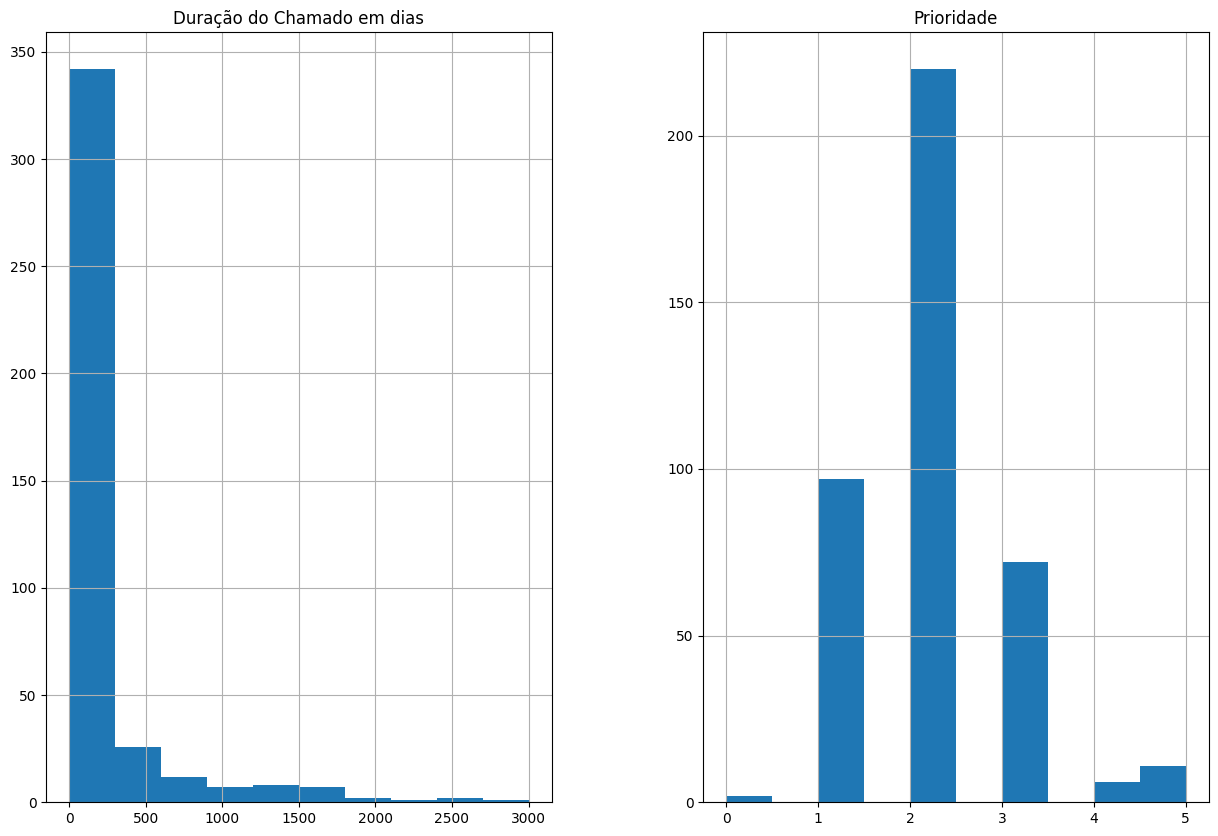

In [ ]:
## Histograma
# Análise dda quantidade de dias que um chamado está registrado no sistema

# Necessário criar um DataFrame sem a coluna 'ID' para o histograma. Assim obtemos somente a variável numérica 'Duração do Chamado em dias'.
df_sem_id = df.drop(columns=['ID'], errors='ignore')

df_sem_id.hist(figsize=(15,10)) # largura / altura
plt.show()

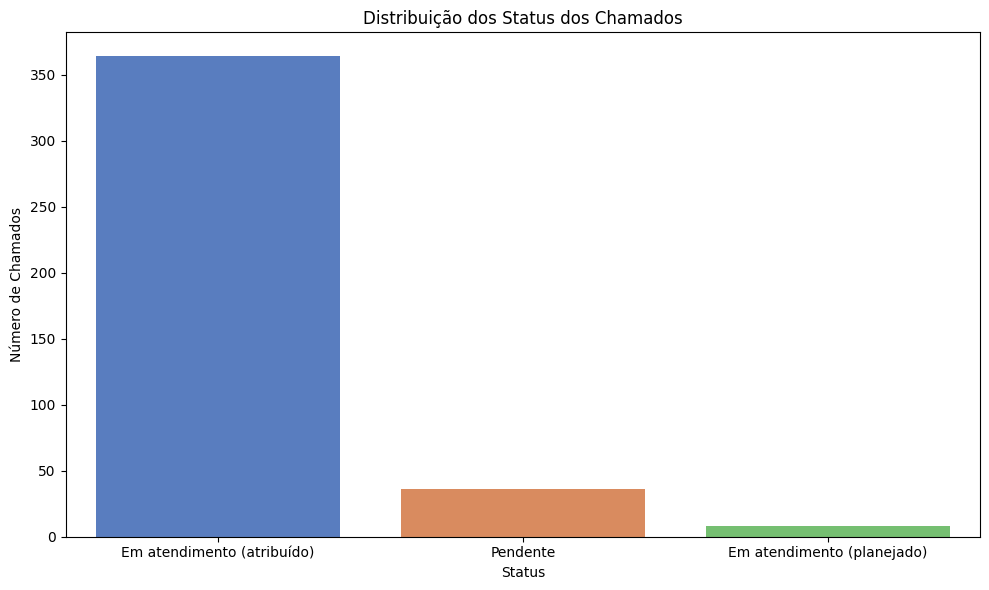

In [ ]:
# Gráfico de Barras
# Análise de como os chamados estão distribuídos e quais suas classes, entre 'Em atendimento (atribuído)', 'Pendente' e 'Em atendimento (planejado)'
qtd_status = df['Status'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=qtd_status.index, y=qtd_status.values, hue=qtd_status.index, palette='muted', legend=False)
plt.title('Distribuição dos Status dos Chamados')
plt.xlabel('Status')
plt.ylabel('Número de Chamados')
plt.tight_layout()
plt.show()

In [ ]:
## Contagem
# Análise da quantidade de Requerentes e de Técnicos presentes
# Requerente é aquele que faz a solicitação para o Setor de TI

num_requerentes = df['Requerente - Requerente'].nunique()
num_tecnicos = df['Atribuído - Técnico'].nunique()

print(f"Quantidade de Requerentes diferentes: {num_requerentes}")
print(f"Quantidade de Técnicos diferentes: {num_tecnicos}")

Quantidade de Requerentes diferentes: 89
Quantidade de Técnicos diferentes: 35


In [ ]:
## Contagem
# Análise da quantidade de chamados feitos por cada Requerente

print("Quantidade de chamados por Requerente:")
display(df['Requerente - Requerente'].value_counts())

Quantidade de chamados por Requerente:


,count
Requerente - Requerente,
Rhavi Sampaio,43
Ana Sales,38
Yasmin da Rocha,35
Marcos Vinicius Casa Grande,24
Dr. Pedro Lucas Castro,22
...,...
Pedro Lucas Viana,1
Isaac Rezende,1
Sr. Asafe Guerra,1


In [ ]:
## Contagem
# Análise da quantidade de chamados atribuídos a cada Técnico

print("Quantidade de chamados por Técnico:")
display(df['Atribuído - Técnico'].value_counts())

Quantidade de chamados por Técnico:


,count
Atribuído - Técnico,
Josué da Mata,39
Camila Rodrigues,34
Giovanna Silva,27
Srta. Caroline Leão,22
Sr. Ravi Lucca Sá,20
Srta. Allana Correia,18
João Guilherme Ramos,17
Dr. Davi Miguel Rios,17
Dr. Mathias Monteiro,17


In [ ]:
## Contagem
# Análise da quantidade de chamados por Prioridade
# A coluna Prioridade está organizada da seguinte forma:
# Muito baixa: 0
# Baixa: 1
# Média: 2
# Alta: 3
# Muito alta: 4
# Crítica: 5

print("Quantidade de chamados por Prioridade:")
display(df['Prioridade'].value_counts().sort_index()) # sort_index organiza em ordem crescente

# Para verificar em uma Prioridade específica
priority_2_count = df[df['Prioridade'] == 2].shape[0]
print(f"Quantidade de chamados com Prioridade '2': {priority_2_count}")

Quantidade de chamados por Prioridade:


,count
Prioridade,
0,2
1,97
2,220
3,72
4,6
5,11


Quantidade de chamados com Prioridade '2': 220


####Seleção, Limpeza e Pré-processamento de Texto

Realização das seguintes etapas:
1. Seleciona somente as Categorias importantes para análise
2. Faz a Limpeza de Texto:
 - Converte o texto para minúsculas.
 - Remove caracteres não alfabéticos (mantendo apenas letras e espaços).
 - Tokeniza o texto em palavras.
 - Remove stopwords (palavras comuns que não adicionam / alteram significado, como 'de', 'a', 'o').
 - Junção das palavras processadas em uma string.

In [ ]:
##Seleção
df = df[['Título', 'Categoria']]

# remove valores nulos
df = df.dropna()

print("Quantidade de dados:", len(df))
df.head()

Quantidade de dados: 408


,Título,Categoria
0,Revisar politicas fw,TI
1,DNS para rede interna,TI
2,Hospedar [SALA] no POP-SC,TI
3,Implantar spanning tree na rede,TI
4,Separar [ATIVO_REDE] proxy,TI


In [ ]:
# transforma o texto em minúsculas
df['Titulo_limpo'] = df['Título'].str.lower()

# remove números
df['Titulo_limpo'] = df['Titulo_limpo'].str.replace(r'\d+', '', regex=True)

# remove pontuação
df['Titulo_limpo'] = df['Titulo_limpo'].str.replace(r'[^\w\s]', '', regex=True)

# remove stopwords
df['Titulo_limpo'] = df['Titulo_limpo'].apply(
    lambda texto: " ".join([w for w in texto.split() if w not in stop_words])
)

df.head()

,Título,Categoria,Titulo_limpo
0,Revisar politicas fw,TI,revisar politicas fw
1,DNS para rede interna,TI,dns rede interna
2,Hospedar [SALA] no POP-SC,TI,hospedar sala popsc
3,Implantar spanning tree na rede,TI,implantar spanning tree rede
4,Separar [ATIVO_REDE] proxy,TI,separar ativo_rede proxy


In [ ]:
## Análise de distribuição das categorias
df['Categoria'].value_counts()

,count
Categoria,
INFRA,186
TI,113
INFRA+TI,49
LABORATÓRIOS DE INFORMÁTICA,22
CECOM,14
PROGRAMAÇÃO VISUAL,7
AUDIOVISUAL,7
INFRA+AUDIOVISUAL,7
AUDIOVISUAL+TI,3


In [ ]:
## Vetorização (TF-IDF)
vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(df['Titulo_limpo'])
y = df['Categoria']

# Shape nos mostra a tupla (linhas, colunas)
# Linhas são o número de títulos de chamados processados.
# Colunas são o número de características (features) únicas que foram extraídas do texto.
print("Shape de X:", X.shape)

Shape de X: (408, 704)


In [ ]:
## Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
# Regressão Logística
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Naive Bayes Multinomial
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train.toarray(), y_train)

GradientBoostingClassifier()

In [ ]:
## Avaliação: Regressão Logística
y_pred_lr = lr.predict(X_test)

print("===== Logistic Regression =====")
print("Acurácia:", accuracy_score(y_test, y_pred_lr))
print("\nRelatório:\n")
print(classification_report(y_test, y_pred_lr))

===== Logistic Regression =====
Acurácia: 0.6747967479674797

Relatório:

                             precision    recall  f1-score   support

                AUDIOVISUAL       0.00      0.00      0.00         2
             AUDIOVISUAL+TI       0.00      0.00      0.00         1
                      CECOM       0.67      0.50      0.57         4
                      INFRA       0.77      0.82      0.79        56
          INFRA+AUDIOVISUAL       0.00      0.00      0.00         2
                   INFRA+TI       0.67      0.67      0.67        15
LABORATÓRIOS DE INFORMÁTICA       0.50      0.57      0.53         7
         PROGRAMAÇÃO VISUAL       0.33      0.50      0.40         2
                         TI       0.74      0.59      0.66        34

                   accuracy                           0.67       123
                  macro avg       0.41      0.41      0.40       123
               weighted avg       0.69      0.67      0.68       123



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
## Avaliação: Naive Bayes Multinomial
y_pred_nb = nb.predict(X_test)

print("===== Naive Bayes =====")
print("Acurácia:", accuracy_score(y_test, y_pred_nb))
print("\nRelatório:\n")
print(classification_report(y_test, y_pred_nb))

===== Naive Bayes =====
Acurácia: 0.5609756097560976

Relatório:

                             precision    recall  f1-score   support

                AUDIOVISUAL       0.00      0.00      0.00         2
             AUDIOVISUAL+TI       0.00      0.00      0.00         1
                      CECOM       0.00      0.00      0.00         4
                      INFRA       0.52      1.00      0.69        56
          INFRA+AUDIOVISUAL       0.00      0.00      0.00         2
                   INFRA+TI       1.00      0.07      0.12        15
LABORATÓRIOS DE INFORMÁTICA       0.00      0.00      0.00         7
         PROGRAMAÇÃO VISUAL       0.00      0.00      0.00         2
                         TI       0.80      0.35      0.49        34

                   accuracy                           0.56       123
                  macro avg       0.26      0.16      0.14       123
               weighted avg       0.58      0.56      0.46       123



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
## Avaliação: Gradient Boosting
y_pred_gb = gb.predict(X_test.toarray())

print("===== Gradient Boosting =====")
print("Acurácia:", accuracy_score(y_test, y_pred_gb))
print("\nRelatório:\n")
print(classification_report(y_test, y_pred_gb))

===== Gradient Boosting =====
Acurácia: 0.5691056910569106

Relatório:

                             precision    recall  f1-score   support

                AUDIOVISUAL       0.00      0.00      0.00         2
             AUDIOVISUAL+TI       0.00      0.00      0.00         1
                      CECOM       0.00      0.00      0.00         4
                      INFRA       0.57      0.91      0.70        56
          INFRA+AUDIOVISUAL       0.00      0.00      0.00         2
                   INFRA+TI       0.56      0.33      0.42        15
LABORATÓRIOS DE INFORMÁTICA       0.67      0.57      0.62         7
         PROGRAMAÇÃO VISUAL       0.00      0.00      0.00         2
                         TI       0.67      0.29      0.41        34

                   accuracy                           0.57       123
                  macro avg       0.27      0.23      0.24       123
               weighted avg       0.55      0.57      0.52       123



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
### faça isso depois de ter treinado os 3 modelos ###

## Teste manual - Inserindo um novo texto para que os modelos façam uma nova Previsão

# texto de teste
texto = "computador não liga no laboratório"

# aplicar mesma limpeza usada no dataset
texto_limpo = texto.lower()
texto_limpo = re.sub(r'\d+', '', texto_limpo)
texto_limpo = re.sub(r'[^\w\s]', '', texto_limpo)
texto_limpo = " ".join([w for w in texto_limpo.split() if w not in stop_words])

# vetorizar
vetor = vectorizer.transform([texto_limpo])

# previsões
pred_lr = lr.predict(vetor)[0]
pred_nb = nb.predict(vetor)[0]
pred_gb = gb.predict(vetor.toarray())[0]

# resultado
print("Texto original:", texto)
print("Texto limpo:", texto_limpo)
print("\nPrevisões:")
print("Logistic Regression:", pred_lr)
print("Naive Bayes:", pred_nb)
print("Gradient Boosting:", pred_gb)

Texto original: computador não liga no laboratório
Texto limpo: computador liga laboratório

Previsões:
Logistic Regression: LABORATÓRIOS DE INFORMÁTICA
Naive Bayes: INFRA
Gradient Boosting: TI


In [ ]:
### faça isso depois de ter treinado os 3 modelos ###

# texto de teste
texto = "projetor não está funcionando na sala"

# aplicar mesma limpeza usada no dataset
texto_limpo = texto.lower()
texto_limpo = re.sub(r'\d+', '', texto_limpo)
texto_limpo = re.sub(r'[^\w\s]', '', texto_limpo)
texto_limpo = " ".join([w for w in texto_limpo.split() if w not in stop_words])

# vetorizar
vetor = vectorizer.transform([texto_limpo])

# previsões
pred_lr = lr.predict(vetor)[0]
pred_nb = nb.predict(vetor)[0]
pred_gb = gb.predict(vetor.toarray())[0]

# resultado
print("Texto original:", texto)
print("Texto limpo:", texto_limpo)
print("\nPrevisões:")
print("Logistic Regression:", pred_lr)
print("Naive Bayes:", pred_nb)
print("Gradient Boosting:", pred_gb)

Texto original: projetor não está funcionando na sala
Texto limpo: projetor funcionando sala

Previsões:
Logistic Regression: AUDIOVISUAL
Naive Bayes: INFRA
Gradient Boosting: AUDIOVISUAL


In [ ]:
### faça isso depois de ter treinado os 3 modelos ###

# texto de teste
texto = "internet caiu no bloco administrativo"

# aplicar mesma limpeza usada no dataset
texto_limpo = texto.lower()
texto_limpo = re.sub(r'\d+', '', texto_limpo)
texto_limpo = re.sub(r'[^\w\s]', '', texto_limpo)
texto_limpo = " ".join([w for w in texto_limpo.split() if w not in stop_words])

# vetorizar
vetor = vectorizer.transform([texto_limpo])

# previsões
pred_lr = lr.predict(vetor)[0]
pred_nb = nb.predict(vetor)[0]
pred_gb = gb.predict(vetor.toarray())[0]

# resultado
print("Texto original:", texto)
print("Texto limpo:", texto_limpo)
print("\nPrevisões:")
print("Logistic Regression:", pred_lr)
print("Naive Bayes:", pred_nb)
print("Gradient Boosting:", pred_gb)

Texto original: internet caiu no bloco administrativo
Texto limpo: internet caiu bloco administrativo

Previsões:
Logistic Regression: TI
Naive Bayes: INFRA
Gradient Boosting: INFRA


##Resumo

###O que aconteceu no geral?

O principal problema:

 - Desbalanceamento extremo das classes + poucos dados

Impacto direto:

- Os modelos aprenderam bem em classes grandes como INFRA e TI
- Ignoraram classes pequenas com poucos exemplos

Isso gerou:
- precisão = 0 nas classes
- warnings (UndefinedMetricWarning)

Ou seja:

- Os modelos simplesmente não aprenderam nada sobre algumas categorias


###Qual modelo apresentou melhores resultados?
####Regressão Logística foi o Melhor modelo

- Acurácia: 0.67 (maior)

- Melhor equilíbrio geral

- Conseguiu prever mais classes diferentes

Destaque:

- INFRA → muito bom (0.79 f1)
- TI → razoável (0.66 f1)
- INFRA+TI → bom (0.67 f1)

Problema:

- Ignorou classes pequenas (0.00)

Conclusão: modelo mais confiável do experimento

####Gradient Boosting
- Acurácia: 0.57

- Desempenho mediano

Destaque:

- INFRA → bom (0.70 f1)
- LABORATÓRIOS → razoável (0.62 f1)

Problema:

- Baixa generalização
- Muitas classes com 0.00

Conclusão: não ideal para texto

####Naive Bayes Multinomial
- Acurácia: 0.56

- Forte viés para classe majoritária

Comportamento claro:

- INFRA → recall = 1.00 (acertou quase tudo)

Mas:
- ignorou quase todas as outras classes

Isso significa:

- Ele está classificando quase tudo como INFRA

Conclusão: modelo simples, mas enviesado

###Sobre as métricas de avaliação dos modelos:
####Accuracy (Acurácia)
É a proporção de todas as classificações que estavam corretas, sejam elas positivas ou negativas. Mostra o Total de acertos pelo total de exemplos

No nosso caso a melhor acurácia foi de 67%, isto é:

- 67% dos chamados foram classificados corretamente

Um modelo perfeito teria zero falso positivo e negativo e, portanto, uma acurácia de 1,0 ou 100%.

No entanto, quando o conjunto de dados está desequilibrado ou quando um tipo de erro (FN ou FP) é maior que o outro, é melhor otimizar uma das outras métricas.

####Precision (Precisão)
Possui foco nos dados que podem ser falsos positivos.

É a proporção de todas as classificações positivas do modelo que são realmente positivas.

Um modelo perfeito hipotético teria zero falso positivo e, portanto, uma precisão de 1,0.

Em um conjunto de dados desequilibrado em que o número de positivos reais é muito baixo, 1 a 2 exemplos no total, a precisão é menos significativa e menos útil.

A precisão melhora à medida que os falsos positivos diminuem, enquanto o recall melhora quando os falsos negativos diminuem.

Então:
- Precisão baixa = muitos falsos positivos

####Recall
Recall ou também conhecida como taxa de verdadeiro positivo (TVP), ou a proporção de todos os positivos reais que foram classificados corretamente como positivos.

Um modelo perfeito hipotético teria zero falsos negativos e, portanto, um recall (TPR) de 1,0, ou seja, uma taxa de detecção de 100%.

Então:
- Recall baixo = modelo está “perdendo” exemplos

Em um conjunto de dados desbalanceado em que o número de positivos reais é muito baixo, o recall é uma métrica mais significativa do que a acurácia, porque mede a capacidade do modelo de identificar corretamente todas as instâncias positivas.

####F1-score
Faz uma média entre a Precisão e Recall. Varia de 0 a 1, onde 1 indica desempenho perfeito e 0 indica um desempenho ruim.

Melhor métrica para comparar modelos

É especialmente útil em cenários com dados desbalanceados, onde uma classe tem muito mais exemplos que a outra.

####Support (Suporte)
Nos mostra o número de ocorrências reais de cada classe no conjunto de dados de teste. Uma quantidade real de exemplos de cada classe.

O suporte não é uma métrica de desempenho (como a acurácia), mas sim uma métrica de contexto que indica a distribuição real dos dados. Isto é, mostra o desbalanceamento deles.

###Por que esses 3 modelos foram escolhidos?
####Logistic Regression
- Padrão em PLN
- Funciona muito bem com TF-IDF
- Linear → bom para dados esparsos

####Naive Bayes (Multinomial)
- Clássico para texto
- Baseado em probabilidade
- Muito rápido e eficiente

####Gradient Boosting
- Modelo mais avançado (ensemble)
- Incluído para comparação
- Mostra diferença entre: modelos lineares vs não-lineares

###Quais outros modelos poderiam ser usados?
####SVM (LinearSVC)
- Geralmente um dos melhores para texto
- Muito usado em classificação de texto

####Random Forest
- Alternativa ao Gradient Boosting
- Melhor para dados tabulares

####Redes neurais (MLP)
- Podem capturar padrões mais complexos
- Mas precisam de mais dados

####Modelos modernos (extra)
- BERT (transformers)
- Word embeddings